# 02 - Telemetry, context, or both?

`01_headroom.ipynb` established what kind of limitation we are up against. This
notebook tests the lever that follows from it: giving the model information it has
never had, rather than more capacity.

The information in question is **job context** - above all, how long the job has
already been running. It is available at prediction time, it has never been offered
to any model in this project, and `eda/` gives a strong reason to expect it to
matter: **92.6 % of TIMEOUT jobs end within 60 seconds of a whole hour**, against
1.9 % of COMPLETED jobs, with modal runtimes at 1, 2, 3, 24, 48 and 120 hours. Those
are walltime limits typed by hand into a submission script. A model that knows the
elapsed time and the queue can learn them; a model that sees only node telemetry
cannot.

## Why this must be reported as three models, not one

TIMEOUT is 70 % of the positive class. If context features lift the pooled number,
a single reported figure would be uninterpretable - the reader could not tell
whether the model predicts *node failure* or merely *reads a clock*. That is exactly
the ambiguity that makes very high published scores on this task impossible to
assess.

So three feature sets are trained and reported separately:

| set | columns | question it answers |
|---|---|---|
| **T** telemetry | the 56 `eda/` aggregates | can node health predict failure? |
| **C** context | elapsed time, queue, job size, clock | can job metadata alone predict it? |
| **T+C** both | 56 + context | do they add anything to each other? |

and each is evaluated **per failure mode**, because the whole hypothesis is that
context predicts walltime exhaustion while telemetry is what would have to predict
hardware failure.

## Pre-registration

**C1.** Context alone (**C**) will beat telemetry alone (**T**) on the pooled label.

**C2.** The gain will be concentrated in TIMEOUT. On hardware failures
(FAILED / OUT_OF_MEMORY / NODE_FAIL) context will add little or nothing.

**C3.** If C1 and C2 both hold, the honest headline is *"walltime exhaustion is
predictable from elapsed time; hardware failure is not predictable from node
telemetry"* - a finding about the task, not a better failure predictor.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, n_jobs=-1, random_state=0)
HARDWARE = ("FAILED", "OUT_OF_MEMORY", "NODE_FAIL")
N_BOOT = 200

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print("setup ok")

setup ok


## Step 1 - Build the context features

Every one of these is known **at the moment the window ends**, while the job is
still running. Nothing here uses the job's end time, its final state, or its total
duration - those are the label, and using them would be leakage.

* `elapsed_h` - hours since the job started
* `sec_into_hour`, `sec_to_next_hour` - position within the current wall-clock hour,
  which is where the walltime-limit clustering lives
* `elapsed_hours_floor` - the integer hour the job is in
* `queue_code`, `numnodes`, `numcores` - known at submission
* `hour_of_day`, `dow` - the cluster has a diurnal usage pattern

In [2]:
w = pd.read_parquet(EDA / "windows.parquet")
jobs = pd.read_parquet(EDA / "jobs.parquet",
                       columns=["slurm_id", "start_date", "numcores"])
w = w.merge(jobs, on="slurm_id", how="left")

TELEMETRY = [c for c in w.columns if "__" in c]

elapsed_s = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"]           = elapsed_s / 3600.0
w["sec_into_hour"]       = elapsed_s % 3600.0
w["sec_to_next_hour"]    = 3600.0 - (elapsed_s % 3600.0)
w["elapsed_hours_floor"] = np.floor(elapsed_s / 3600.0)
w["queue_code"]          = w.nodetypes.astype(str).astype("category").cat.codes
w["hour_of_day"]         = w.t_end.dt.hour
w["dow"]                 = w.t_end.dt.dayofweek

CONTEXT = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
           "queue_code", "numnodes", "numcores", "hour_of_day", "dow"]
BOTH = TELEMETRY + CONTEXT

tr, te = w[w.split == "train"], w[w.split == "test"]
print(f"telemetry {len(TELEMETRY)} cols   context {len(CONTEXT)} cols   both {len(BOTH)}")
print(f"train {len(tr):,}   test {len(te):,}")
print()
print("sanity: elapsed_h must never exceed the job's own runtime")
print(w.groupby(w.state.astype(str)).elapsed_h.describe()[["count", "50%", "max"]].round(2).to_string())

telemetry 56 cols   context 9 cols   both 65
train 915,508   test 142,309

sanity: elapsed_h must never exceed the job's own runtime


                  count    50%     max
state                                 
COMPLETED      630123.0   7.41  119.00
FAILED          58822.0  11.25   92.50
NODE_FAIL        2533.0   9.58   24.33
OUT_OF_MEMORY    6981.0  19.41   90.33
TIMEOUT        359358.0  25.33  120.00


## Step 2 - Evaluation harness

`ap_mode` evaluates a scored test set restricted to one failure mode: it keeps every
negative window and only those positives belonging to the requested states. That
keeps the negative population - and therefore the operating conditions - identical
across modes, so the numbers are comparable.

In [3]:
def ap_ci(y, score, groups, n_boot=N_BOOT, seed=1):
    rng = np.random.default_rng(seed)
    ap = average_precision_score(y, score)
    uniq, inv = np.unique(groups, return_inverse=True)
    order  = np.argsort(inv, kind="stable")
    bounds = np.r_[0, np.cumsum(np.bincount(inv, minlength=len(uniq)))]
    by_g   = [order[bounds[g]:bounds[g + 1]] for g in range(len(uniq))]
    boots  = np.empty(n_boot)
    for b in range(n_boot):
        rows = np.concatenate([by_g[g] for g in rng.integers(0, len(uniq), len(uniq))])
        yb = y[rows]
        boots[b] = average_precision_score(yb, score[rows]) if yb.sum() else np.nan
    return ap, *np.nanpercentile(boots, [2.5, 97.5])

def ap_mode(te_df, score, states=None):
    """AP over all negatives plus only the positives belonging to `states`.

    Keeping every negative means the operating conditions are identical across
    modes, so the resulting numbers are comparable to each other."""
    y = te_df.y.to_numpy()
    if states is None:
        keep = np.ones(len(y), bool)
    else:
        st = te_df.state.astype(str).to_numpy()
        keep = (y == 0) | np.isin(st, states)
    yk, sk = y[keep], score[keep]
    if yk.sum() == 0:
        return np.nan, np.nan, 0, np.nan
    ap, base = average_precision_score(yk, sk), yk.mean()
    return ap, base, int(yk.sum()), ap / base

print("harness defined")

harness defined


## Step 3 - Train the three models

In [4]:
sets = {"T  telemetry": TELEMETRY, "C  context": CONTEXT, "T+C  both": BOTH}
scores, rows = {}, []
for name, cols in sets.items():
    m = lgb.LGBMClassifier(**PARAMS).fit(tr[cols], tr.y)
    sc = m.predict_proba(te[cols])[:, 1]
    scores[name] = sc
    ap, lo, hi = ap_ci(te.y.to_numpy(), sc, te.slurm_id.to_numpy())
    base = te.y.mean()
    rows.append(dict(features=name, n_cols=len(cols), ap=ap, lo=lo, hi=hi,
                     lift=ap / base))
    print(f"{name:14s} {len(cols):3d} cols   test AP {ap:.4f}  "
          f"[{lo:.4f}, {hi:.4f}]  = {ap/base:.2f}x   [{time.time()-t0:.0f}s]")

pooled = pd.DataFrame(rows)
facts["pooled"] = {r.features: float(r.ap) for _, r in pooled.iterrows()}
print()
print(f"C1  context beats telemetry on the pooled label : "
      f"{'CONFIRMED' if pooled.iloc[1].ap > pooled.iloc[0].ap else 'REJECTED'}")

T  telemetry    56 cols   test AP 0.0797  [0.0606, 0.1289]  = 1.95x   [19s]


C  context       9 cols   test AP 0.1903  [0.1446, 0.2373]  = 4.65x   [27s]


T+C  both       65 cols   test AP 0.1941  [0.1410, 0.2550]  = 4.74x   [44s]

C1  context beats telemetry on the pooled label : CONFIRMED


## Step 4 - Per failure mode

This is where C2 is decided. If context is a clock rather than a failure detector,
its advantage should vanish on hardware failures.

In [5]:
MODES = {"all failures": None, "TIMEOUT": ("TIMEOUT",), "hardware only": HARDWARE,
         "FAILED": ("FAILED",), "NODE_FAIL": ("NODE_FAIL",),
         "OUT_OF_MEMORY": ("OUT_OF_MEMORY",)}
grid = []
for mode, states in MODES.items():
    for name in sets:
        ap, base, npos, lift = ap_mode(te, scores[name], states)
        grid.append(dict(mode=mode, features=name, positives=npos,
                         base=base, ap=ap, lift=lift))
G = pd.DataFrame(grid)
G.to_csv(DATA / "mode_grid.csv", index=False)

piv_lift = G.pivot(index="mode", columns="features", values="lift").round(2)
piv_ap   = G.pivot(index="mode", columns="features", values="ap").round(4)
print("LIFT over each mode's own baseline")
print(piv_lift.to_string())
print()
print("average precision")
print(piv_ap.to_string())

LIFT over each mode's own baseline
features       C  context  T  telemetry  T+C  both
mode                                              
FAILED               1.99          1.18       1.50
NODE_FAIL            5.22          2.23       3.34
OUT_OF_MEMORY        4.15          8.07       8.46
TIMEOUT              6.98          2.22       7.22
all failures         4.65          1.95       4.74
hardware only        2.26          1.55       1.98

average precision
features       C  context  T  telemetry  T+C  both
mode                                              
FAILED             0.0189        0.0113     0.0143
NODE_FAIL          0.0097        0.0041     0.0062
OUT_OF_MEMORY      0.0049        0.0096     0.0101
TIMEOUT            0.2036        0.0649     0.2104
all failures       0.1903        0.0797     0.1941
hardware only      0.0283        0.0194     0.0248


In [6]:
tmo = G[(G["mode"] == "TIMEOUT")].set_index("features").lift
hw  = G[(G["mode"] == "hardware only")].set_index("features").lift
facts["timeout_lift"]  = {k: float(v) for k, v in tmo.items()}
facts["hardware_lift"] = {k: float(v) for k, v in hw.items()}

gain_tmo = tmo["T+C  both"] / tmo["T  telemetry"]
gain_hw  = hw["T+C  both"] / hw["T  telemetry"]
facts["context_gain_timeout"]  = float(gain_tmo)
facts["context_gain_hardware"] = float(gain_hw)

print(f"adding context multiplies TIMEOUT lift by        {gain_tmo:.2f}x")
print(f"adding context multiplies hardware-failure lift by {gain_hw:.2f}x")
print()
print(f"C2  the gain is concentrated in TIMEOUT : "
      f"{'CONFIRMED' if gain_tmo > gain_hw * 1.5 else 'NOT CONFIRMED - context helps both'}")

adding context multiplies TIMEOUT lift by        3.24x
adding context multiplies hardware-failure lift by 1.28x

C2  the gain is concentrated in TIMEOUT : CONFIRMED


## Step 5 - Which context feature is doing the work?

In [7]:
m_ctx = lgb.LGBMClassifier(**PARAMS).fit(tr[CONTEXT], tr.y)
imp = pd.Series(m_ctx.booster_.feature_importance("gain"), index=CONTEXT)
imp = (100 * imp / imp.sum()).sort_values(ascending=False)
print("share of total split gain, context-only model:")
print(imp.round(1).to_string())
facts["context_importance"] = {k: float(v) for k, v in imp.items()}

share of total split gain, context-only model:
elapsed_hours_floor    28.0
numcores               19.6
queue_code             14.8
dow                    12.6
elapsed_h              12.1
hour_of_day            11.9
sec_into_hour           0.5
sec_to_next_hour        0.3
numnodes                0.1


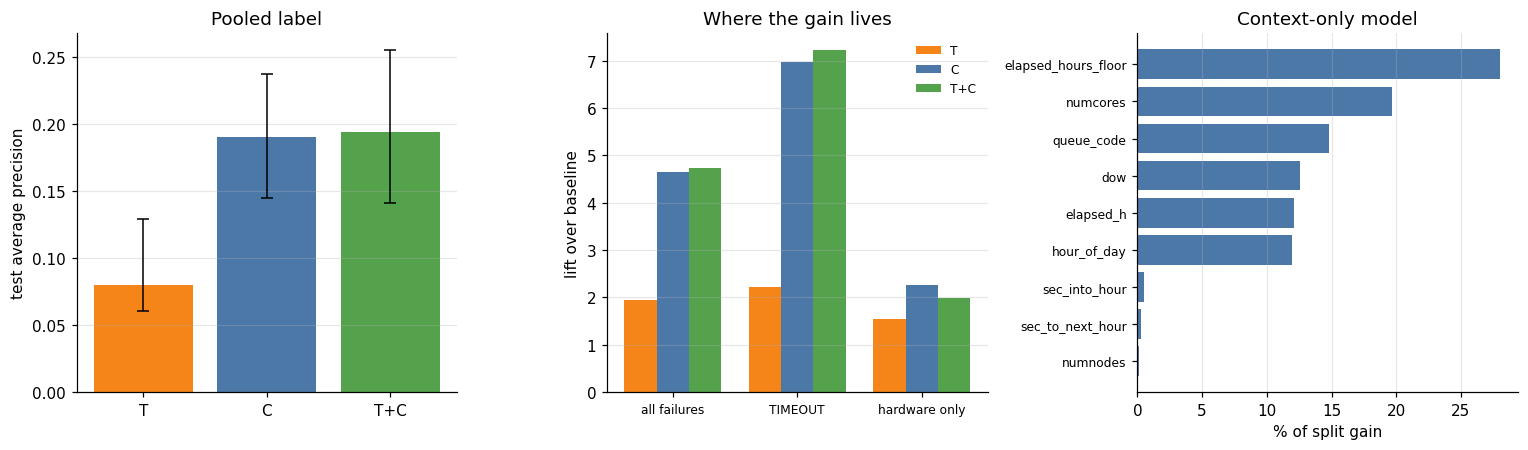

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

x = np.arange(len(pooled))
ax[0].bar(x, pooled.ap, color=["#f58518", "#4c78a8", "#54a24b"])
ax[0].errorbar(x, pooled.ap, yerr=[pooled.ap - pooled.lo, pooled.hi - pooled.ap],
               fmt="none", ecolor="k", capsize=4, lw=1)
ax[0].set_xticks(x, [n.split()[0] for n in pooled.features])
ax[0].set(ylabel="test average precision", title="Pooled label")
ax[0].grid(axis="x", visible=False)

order = ["all failures", "TIMEOUT", "hardware only"]
sub = piv_lift.reindex(order)
xx = np.arange(len(order)); wd = 0.26
for i, (col, c) in enumerate(zip(["T  telemetry", "C  context", "T+C  both"],
                                 ["#f58518", "#4c78a8", "#54a24b"])):
    ax[1].bar(xx + (i - 1) * wd, sub[col], wd, label=col.split()[0], color=c)
ax[1].set_xticks(xx, order, fontsize=8)
ax[1].set(ylabel="lift over baseline", title="Where the gain lives")
ax[1].legend(frameon=False, fontsize=8); ax[1].grid(axis="x", visible=False)

ax[2].barh(range(len(imp))[::-1], imp.to_numpy(), color="#4c78a8")
ax[2].set_yticks(range(len(imp))[::-1], imp.index, fontsize=8)
ax[2].set(xlabel="% of split gain", title="Context-only model")
ax[2].grid(axis="y", visible=False)

plt.tight_layout(); save(fig, "02_context.png"); plt.show()

## Step 6 - Verdict

In [9]:
json.dump(facts, open(DATA / "facts_context.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k}: {v}")
print(f"\n[{time.time()-t0:.0f}s total]")

pooled: {'T  telemetry': 0.07971240373447593, 'C  context': 0.1902522029597924, 'T+C  both': 0.1941111813299412}
timeout_lift: {'T  telemetry': 2.224855586048277, 'C  context': 6.983580772089213, 'T+C  both': 7.216428750776181}
hardware_lift: {'T  telemetry': 1.5504823660141729, 'C  context': 2.262953047336815, 'T+C  both': 1.9808110876656948}
context_gain_timeout: 3.243549287436579
context_gain_hardware: 1.2775450602239151
context_importance: {'elapsed_hours_floor': 28.00937285279489, 'numcores': 19.643533757990987, 'queue_code': 14.811036927871806, 'dow': 12.576935699005993, 'elapsed_h': 12.126695648464857, 'hour_of_day': 11.9176709122332, 'sec_into_hour': 0.49692004080822894, 'sec_to_next_hour': 0.28359039206480485, 'numnodes': 0.1342437687652353}

[50s total]


### How this must be written up

If C1 and C2 hold, the number to quote is **not** the pooled one. The pooled figure
mixes a clock with a failure detector and would overstate what node telemetry can
do. Report the grid: telemetry / context / both, crossed with TIMEOUT / hardware.

Two honest sentences follow from it. Walltime exhaustion is largely predictable, and
cheaply, from information the scheduler already has - which is useful, and is a
scheduling result rather than a monitoring one. Hardware failure remains poorly
predicted from node telemetry, and adding context does not rescue it.

The failure-mode split is also the answer to any published result that reports a
single very high score on a pooled failure label: without this grid, such a number
cannot be attributed to either mechanism.